![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

**This fork belongs to: Lorena Gómez Diego & Marta Orient Cabañas**

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.


## 0. Imports

For this laboratory you will need the following libraries:

In [23]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


## LO.1. Effective index of a waveguide

### 1.1. Materials

We need the refractive index of each material in the cross-section. There are different options to get this information, such as [RefractiveIndex.info](https://refractiveindex.info/) and the [Material Library from Tidy3D](https://docs.flexcompute.com/projects/tidy3d/en/v2.6.0/api/material_library.html#). Here we will load and check the characteristics from the most common materials used in fabrication of photonic circuits: **silicon (Si), silicon nitride (SiNx) and silicon dioxide (SiO2)**.

#### 1.1.1. Crystalline Silicon 

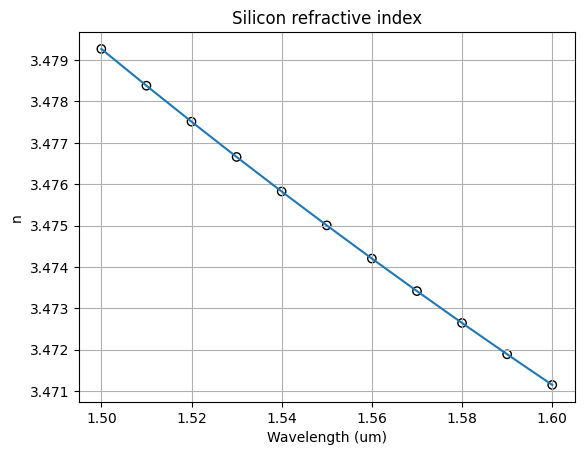

In [24]:
## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
## Check the Tidy3D Docs for more information on the "Variant"

## Index at a particular wavelength
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
plt.scatter(wavelength, si_index,edgecolors='k',facecolors='none')
plt.plot(wavelength,si_index)
plt.title("Silicon refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

#### 1.1.2. Silicon Nitride

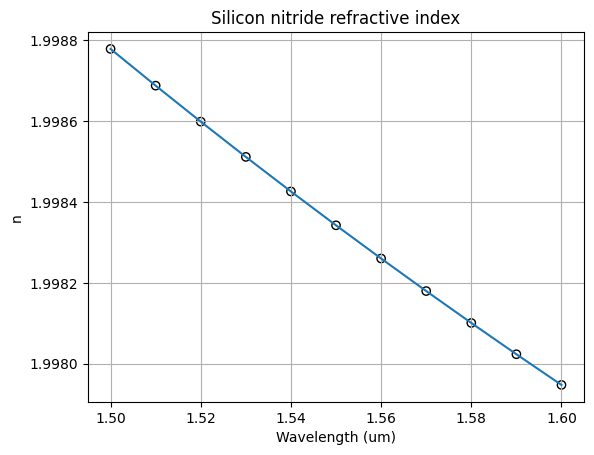

In [25]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f) 
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
plt.scatter(wavelength,nitride_index,edgecolors='k',facecolors='none')
plt.plot(wavelength, nitride_index)
plt.title("Silicon nitride refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()
# less dispersive than silicon, and has a lower index of refraction.

#### 1.1.3. Silicon Dioxide

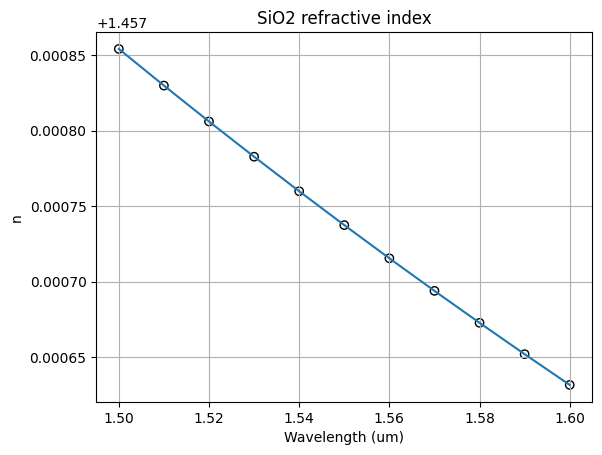

In [26]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.scatter(wavelength,box_index,edgecolors='k',facecolors='None')
plt.plot(wavelength, box_index)
plt.title("SiO2 refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()
#refractive index represents how much the speed of light is reduced in a material, speed of light in the material

### 1.2. Cross - Section Definition

In GDSFactory - Tidy3d modesolver we just have to use the [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. 
It implements the **shallow (rib)** and **shallow (ridge)** waveguide variants. The following example corresponds to a **shallow** waveguide for the **silicon nitride** fabrication proccess, this means that the **cladding** material is silicon dioxide and the **core** material is silicon nitride. The waveguide dimensions are 300 nm (height) and 1.2 um (width). We will check it's behavior at 1.55 um. 

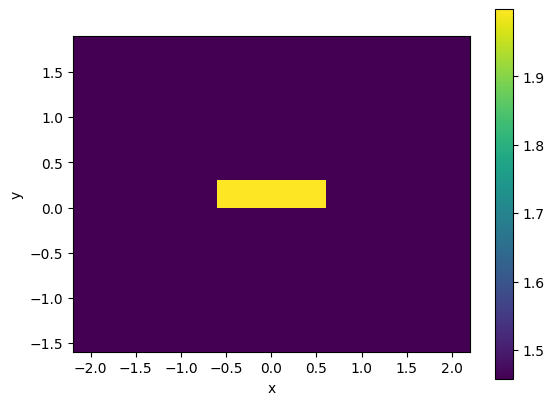

In [27]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=10, # Targeted number of modes to find --> !!! This will return the modes specified, and is labour of the designer whether the mode is guided or not
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index() # to propaagate is necesary that effective index must be higher than the cladding index.

### 1.3. Simulations

#### 1.3.1. Numerical results

We can find the effective index (n_eff), TE and TM fraction for each particular cross-section.

In [28]:
deep_waveguide.n_eff 
# Determines the confination of the mode in the core, the closer the effective index is to the core index, the more confined the mode is in the core. 
# If the effective index is close to the cladding index, then the mode is less confined in the core and more in the cladding.
# In this case, the limits are between 1.457 and 2.0.

# The index of the core must be greater than the index of the cladding in order to have guided modes.
# the number of modes is 2, only first and second propagate, because its effective index is more than 1,457.
# the imaginary part, represents the losses of the mode, and in this case is 0, which means that there are no losses in the waveguide.

2026-03-15 11:58:58.022 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c606ce1889946bec.npz.


array([1.60524792+0.00010066j, 1.52829803+0.00017753j,
       1.45072999+0.00019228j, 1.43325817+0.00021838j,
       1.42993724+0.00021326j, 1.42923571+0.00021655j,
       1.42318255+0.00021782j, 1.40313586+0.00019992j,
       1.40162838+0.00022366j, 1.39518895+0.0002246j ])

In [29]:
deep_waveguide.fraction_te 
# How the electric fields are distributed in the waveguide (TE modes)

array([0.99505426, 0.01004259, 0.96264794, 0.047651  , 0.01097876,
       0.99610323, 0.00392611, 0.97516221, 0.00483365, 0.9993367 ])

In [30]:
deep_waveguide.fraction_tm
# How the magnetic fields are distributed in the waveguide (TM modes)

# fraction_te + fraction_tm should be equal to 1, if the mode is purely TE or TM, then one of the fractions will be 1 and the other will be 0 (or really close to those numbers). 
# If the mode is hybrid, then both fractions will be between 0 and 1.

array([4.94574358e-03, 9.89957406e-01, 3.73520636e-02, 9.52348999e-01,
       9.89021243e-01, 3.89677438e-03, 9.96073892e-01, 2.48377927e-02,
       9.95166347e-01, 6.63296391e-04])

#### 1.3.4. Plots

Text(0.5, 1.0, 'TE0 - LO1')

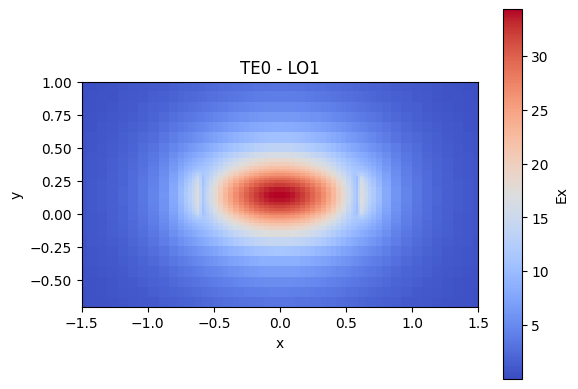

In [31]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('TE0 - LO1') # You might need this later :) 
# We observe discontinuities at the walls along the x-axis, and we see that the field is confined within the core
# neff changes this way with wavelength, comparison between different waveguide cross-sections, etc.


Text(0.5, 1.0, 'TM0 - LO1')

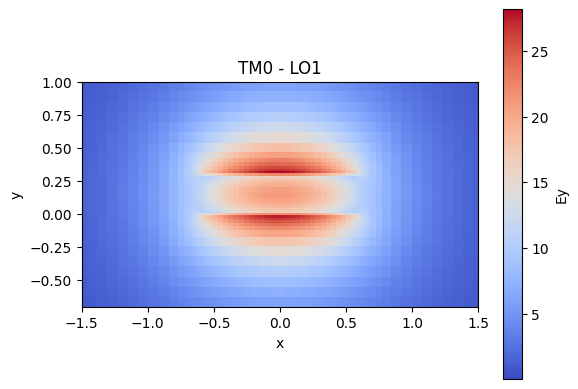

In [32]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
# we see that we have more interaction outside the core
plt.title('TM0 - LO1')

Text(0.5, 1.0, 'Licky mode TE - LO1')

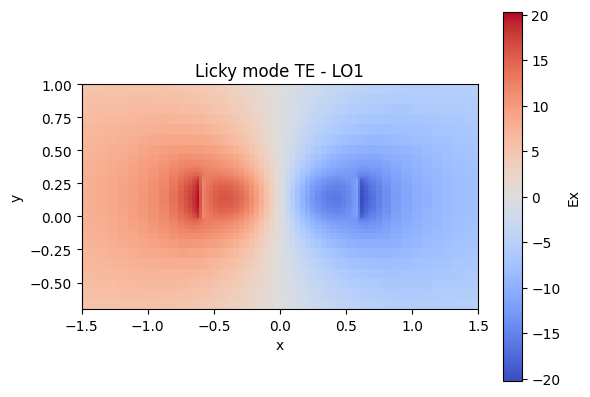

In [33]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
# we see the difference in polarities, which gives a 0 in the field propagation at the center, and we see that the field extends more outside the core, which is typical of higher-order modes.
plt.title('Licky mode TE - LO1')

Text(0.5, 1.0, 'Licky mode TM - LO1')

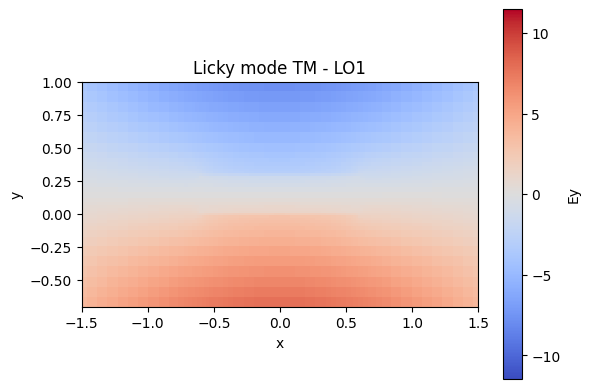

In [34]:
deep_waveguide.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) 
# this representation is nonsense, just for us to know, as we already checked that the mode is not guided --> licky mode
plt.title('Licky mode TM - LO1')


**Important** 
These results are derived from a numerical method used to solve the EM problem, so they must always be interpreted carefully to assess their accuracy. You must check, for instance, if the value of each index neff is higher than the refractive index of the cladding. 

## LO.2. Wavelength behavior

- Let's find the wavelength dependence of the effective index of the SiNx deep waveguide described in LO1. Change the wavelength used at the waveguide cross-section function, it could be a vector also. 

2026-03-15 11:58:58.988 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.


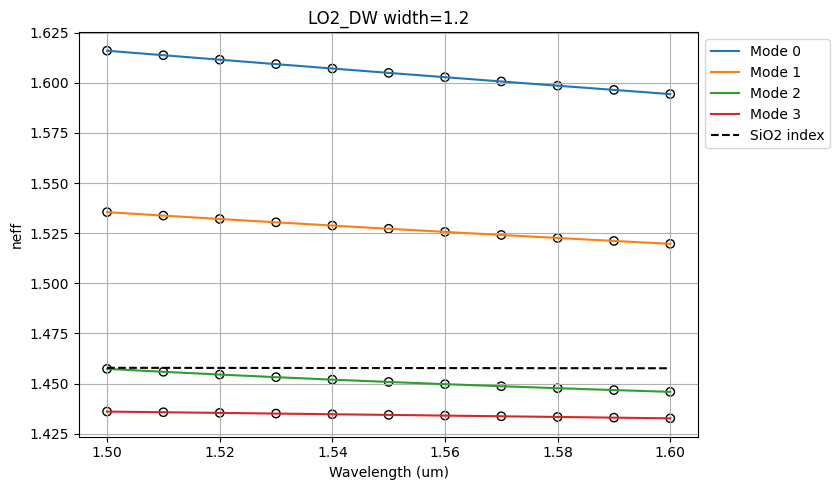

In [35]:
# The wavelength could be a vector also
wavelength = np.linspace(1500, 1600, 11) * nm # Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector
plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"LO2_DW width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

- Repeat the analysis for a **shallow**ly etched waveguide with a 150 nm slab heigth. 

2026-03-15 11:58:59.231 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf0af488213d9e23.npz.


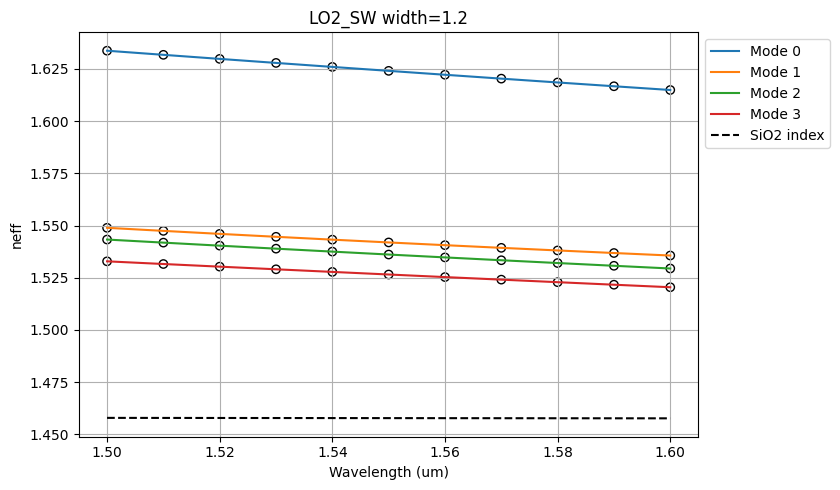

In [36]:
# Shallow waveguide example (core_height=300nm, slab=150nm, width=1.2um)
wavelength = np.linspace(1500, 1600, 11) * nm #Established in pptx

shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_thickness=300 * nm,
    slab_thickness=150 * nm,
    core_material='sin',
    clad_material='sio2',
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

res_neff_s = shallow_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te_s = shallow_waveguide.fraction_te # Wavelength-dependent vector
res_tm_s =shallow_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff_s[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff_s[:,k].real,label=f'Mode {k}')
plt.title(f"LO2_SW width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])



## LO.3. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/10 [00:00<?, ?it/s]

2026-03-15 11:58:59.462 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-03-15 11:58:59.469 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-03-15 11:58:59.472 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ccd09e642d54ed9e.npz.
2026-03-15 11:58:59.474 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bd0ebb0b8e1dda50.npz.
2026-03-15 11:58:59.476 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d4c0f75aabdd9690.npz.
2026-03-15 11:58:59.479 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_65a4004dca43601c.npz.
2026-03-15 11:58:59.481 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bcaefffe13a550c8.npz.
2026-03-15 11:58:59.483 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dc90d742fae9dc78.npz.


  0%|          | 0/10 [00:00<?, ?it/s]

2026-03-15 11:58:59.499 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-03-15 11:58:59.503 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cad20f99025f789a.npz.
2026-03-15 11:58:59.507 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ccd09e642d54ed9e.npz.
2026-03-15 11:58:59.510 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bd0ebb0b8e1dda50.npz.
2026-03-15 11:58:59.512 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d4c0f75aabdd9690.npz.
2026-03-15 11:58:59.513 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_65a4004dca43601c.npz.
2026-03-15 11:58:59.516 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bcaefffe13a550c8.npz.
2026-03-15 11:58:59.519 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dc90d742fae9dc78.npz.


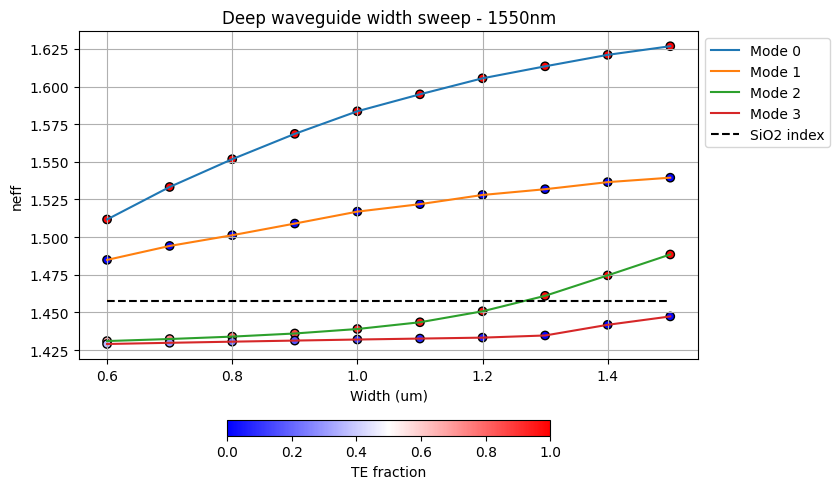

In [37]:
# The wavelength is fixed for the sweep
wavelength = 1550 * nm  # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

# Sweep widths from 0.6 to 1.6 um with step 0.1 um
w = np.arange(0.6, 1.6 , 0.1)  # widths in um

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                             core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.4. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Consider: 

The transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\gamma(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\gamma(\lambda)\}\,z}\,
    e^{\mathrm{Im}\{\gamma(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda) = \mathrm{Re}\{\gamma(\lambda)\}\,z
= \frac{2\pi}{\lambda}\,n_\mathrm{eff}(\lambda).
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the values for n, ng and D of the following waveguides: 
        - Deep waveguide, height = 300nm, width = 1.2um 
        - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.


Comparison at lambda0 = 1550 nm
Structure  Mode              neff               ng            D [s^2/m]
-------------------------------------------------------
Deep       TE0           1.604917         1.939991           -1.007e-15
Deep       TM0           1.527189         1.772025           -1.591e-15
Shallow    TE0           1.624091         1.915762           -9.895e-16
Shallow    TM0           1.541895         1.747423           -1.531e-15


/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0, 0.5, 'neff')

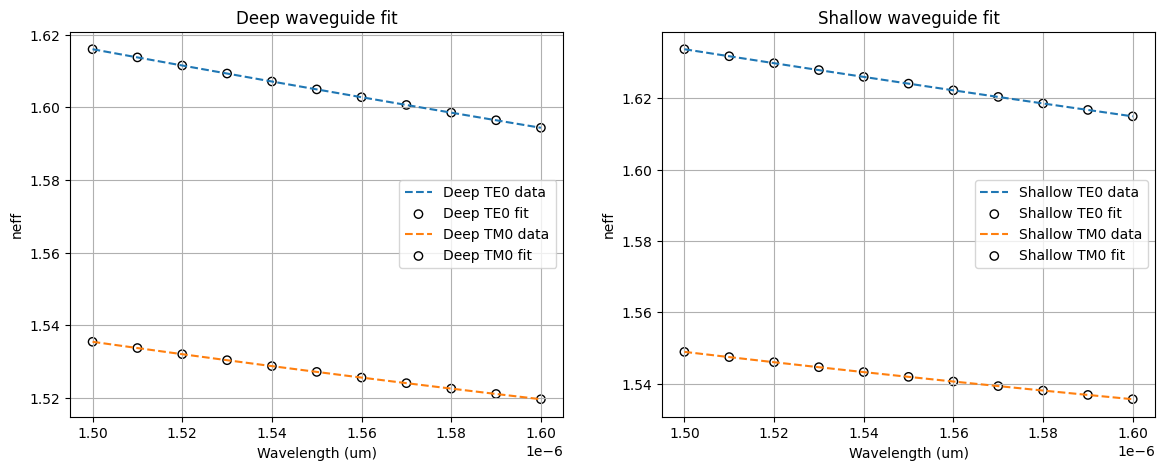

In [38]:
# Compact-model fit (2nd order) for deep and shallow waveguides 
lambda0_m =  1550 * 1e-9 
wavelength = np.linspace(1500, 1600, 11) * 1e-9     
n10_deep,n11_deep,n2_deep,n3_deep=[],[],[],[]
n10_sh,n11_sh,n2_sh,n3_sh = [],[],[],[]
for i in range(len(wavelength)):                          # reference wavelength (m)
    x = wavelength- wavelength[i]                   
    y_deep = res_neff[:, 0:2]  
    p_deep = np.polyfit(x, y_deep, 2)  
    n10_deep.append(p_deep[2,0])
    n11_deep.append(p_deep[2,1])

    y_shallow = shallow_waveguide.n_eff[:, 0:2] # using L02 shallow waveguide results
    p_shallow = np.polyfit(x, y_shallow, 2)
    n10_sh.append(p_shallow[2,0])
    n11_sh.append(p_shallow[2,1])

# Fit TE0 (mode 0) and TM0 (mode 1): deep at lambda0_ref=1550nm
x= wavelength - lambda0_m
p_deep = np.polyfit(x, res_neff[:, 0:2], 2)
n10_deep = p_deep[2, 0] + p_deep[1, 0] * x + p_deep[0, 0] * x**2  # fitted TE0 curve
n11_deep = p_deep[2, 1] + p_deep[1, 1] * x + p_deep[0, 1] * x**2  # fitted TM0 curve

# Fit TE0 (mode 0) and TM0 (mode 1): shallow
p_shallow = np.polyfit(x, shallow_waveguide.n_eff[:, 0:2], 2)
n10_sh = p_shallow[2, 0] + p_shallow[1, 0] * x + p_shallow[0, 0] * x**2
n11_sh = p_shallow[2, 1] + p_shallow[1, 1] * x + p_shallow[0, 1] * x**2
c0=td.C_0 * 1e6

ng_deep_te0 = p_deep[2, 0] - p_deep[1, 0] * lambda0_m
ng_deep_tm0 = p_deep[2, 1] - p_deep[1, 1] * lambda0_m
D_deep_te0 = -2 * lambda0_m * p_deep[0, 0] / c0
D_deep_tm0 = -2 * lambda0_m * p_deep[0, 1] / c0

ng_sh_te0 = p_shallow[2, 0] - p_shallow[1, 0] * lambda0_m
ng_sh_tm0 = p_shallow[2, 1] - p_shallow[1, 1] * lambda0_m
D_sh_te0 = -2 * lambda0_m * p_shallow[0, 0] / c0
D_sh_tm0 = -2 * lambda0_m * p_shallow[0, 1] / c0
# Comparison table
print(f"\nComparison at lambda0 = {lambda0_m*1e9:.0f} nm")
print(f"{'Structure':<10} {'Mode':<5} {'neff':>16} {'ng':>16} {'D [s^2/m]':>20}")
print("-" * 55)
print(f"{'Deep':<10} {'TE0':<5} {n10_deep[5].real:>16.6f} {ng_deep_te0.real:>16.6f} {D_deep_te0.real:>20.3e}")
print(f"{'Deep':<10} {'TM0':<5} {n11_deep[5].real:>16.6f} {ng_deep_tm0.real:>16.6f} {D_deep_tm0.real:>20.3e}")
print(f"{'Shallow':<10} {'TE0':<5} {n10_sh[5].real:>16.6f} {ng_sh_te0.real:>16.6f} {D_sh_te0.real:>20.3e}")
print(f"{'Shallow':<10} {'TM0':<5} {n11_sh[5].real:>16.6f} {ng_sh_tm0.real:>16.6f} {D_sh_tm0.real:>20.3e}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.grid()
ax2.grid()
ax1.plot(wavelength, res_neff[:,0], label='Deep TE0 data ', linestyle='--')
ax1.scatter(wavelength, n10_deep,edgecolors='k', facecolors='none', label='Deep TE0 fit')
ax1.plot(wavelength, res_neff[:,1], label='Deep TM0 data', linestyle='--')
ax1.scatter(wavelength, n11_deep,edgecolors='k', facecolors='none', label='Deep TM0 fit')    
ax1.legend()
ax1.set_title("Deep waveguide fit") 
ax1.set_xlabel("Wavelength (um)")
ax1.set_ylabel("neff")
ax2.plot(wavelength, shallow_waveguide.n_eff[:,0].real, label='Shallow TE0 data', linestyle='--')
ax2.scatter(wavelength, n10_sh,edgecolors='k', facecolors='none', label='Shallow TE0 fit')
ax2.plot(wavelength, shallow_waveguide.n_eff[:,1].real, label='Shallow TM0 data', linestyle='--')
ax2.scatter(wavelength, n11_sh,edgecolors='k', facecolors='none', label='Shallow TM0 fit')
ax2.legend()
ax2.set_title("Shallow waveguide fit")
ax2.set_xlabel("Wavelength (um)")
ax2.set_ylabel("neff")

## LO.5. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

2026-03-15 12:01:19.832 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1592dba1d8e935a8.npz.


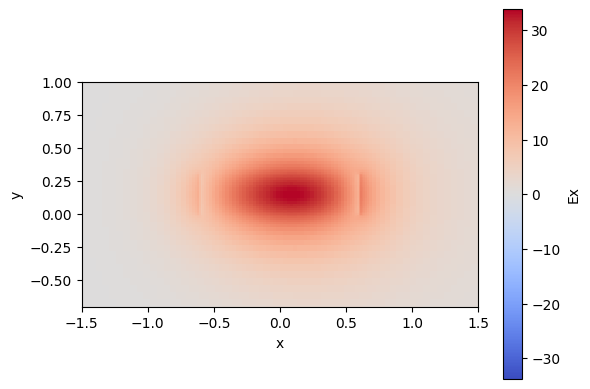

In [43]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/10 [00:00<?, ?it/s]

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

Text(0, 0.5, 'Mismatch (dB)')

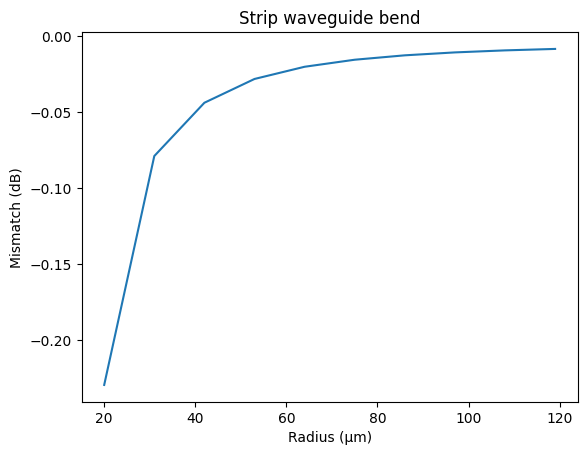

In [40]:
radii = np.arange(20.0, 120,11)
mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


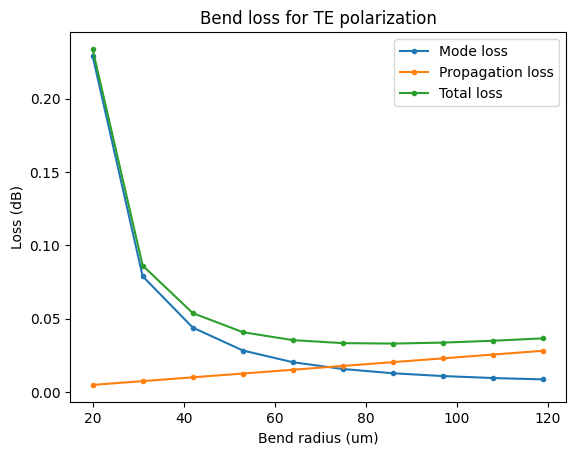

In [41]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".-", label="Mode loss")
plt.plot(radii, propagation_loss, ".-", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".-", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. Consider safe means less than 0.1 dB/90º

  0%|          | 0/6 [00:00<?, ?it/s]

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

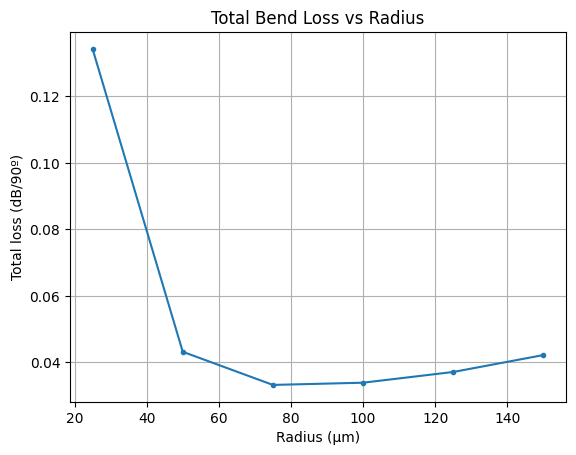

In [44]:
radii = np.arange(25.0, 175,25)
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".-")
plt.title("Total Bend Loss vs Radius")
plt.xlabel("Radius (μm)")
plt.ylabel("Total loss (dB/90º)")
plt.grid()



2026-03-15 12:01:55.796 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_13f241434025c7df.npz.
2026-03-15 12:01:55.799 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b6ff729f8004f9b5.npz.
2026-03-15 12:01:55.802 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7ea91cd9428d9d0a.npz.


2026-03-15 12:01:55.805 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1e54718f169a6068.npz.
2026-03-15 12:01:55.807 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c22cfd3c8a2199e6.npz.
2026-03-15 12:01:55.810 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4e9c19381d587e62.npz.


Text(0, 0.5, 'Effective index (neff)')

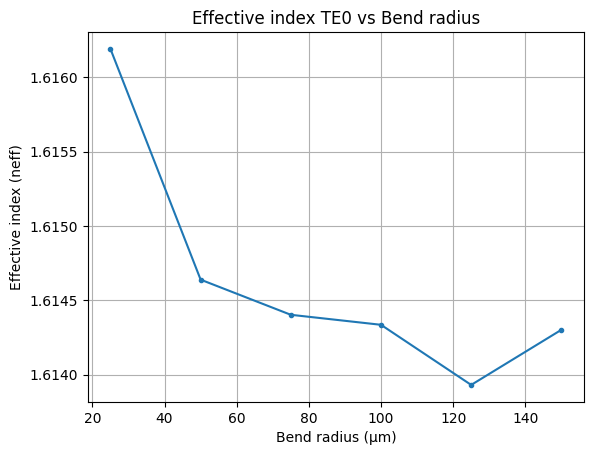

In [45]:
neff_values = []
for R in radii:
    bend_wg = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=1.2,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=1,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=R,
    )
    neff_values.append(bend_wg.n_eff.real)
plt.plot(radii, neff_values, ".-")
plt.grid()
plt.title("Effective index TE0 vs Bend radius")
plt.xlabel("Bend radius (μm)")
plt.ylabel("Effective index (neff)")

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.2. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.3. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

### LO.2 Extended - SOI Wavelength Behavior

Now let's analyze the wavelength dependence for the Silicon-On-Insulator (SOI) technology. We'll use similar wavelength range for comparison.

2026-03-15 12:02:05.802 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_38091c594b211d32.npz.


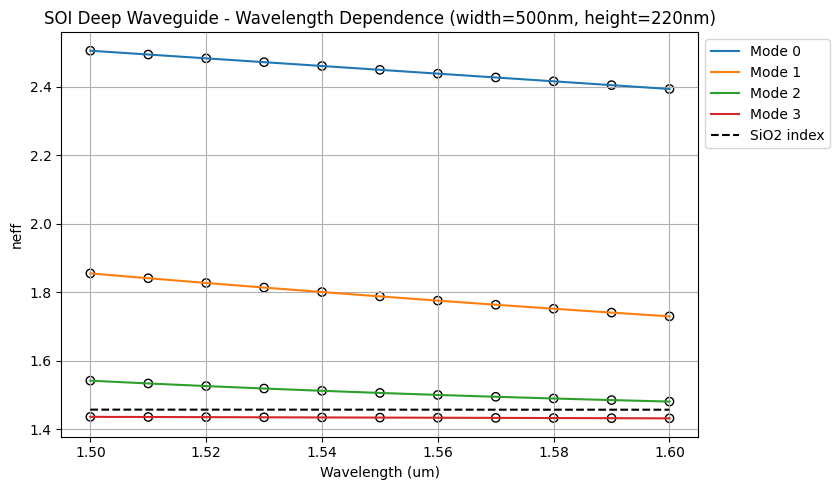

In [46]:
# SOI deep waveguide - wavelength sweep
wavelength_soi = np.linspace(1500, 1600, 11) * nm

soi_deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength_soi,
    core_width=500 * nm,  # 500 nm width
    core_thickness=220 * nm,  # 220 nm height
    slab_thickness=0.0,  # Deep etched
    core_material='si',  # Silicon core
    clad_material='sio2',  # SiO2 cladding
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

res_neff_soi_deep = soi_deep_waveguide.n_eff
res_te_soi_deep = soi_deep_waveguide.fraction_te
res_tm_soi_deep = soi_deep_waveguide.fraction_tm

plt.figure(figsize=(10, 5))
for k in range(res_neff_soi_deep.shape[1]):
    plt.scatter(wavelength_soi, res_neff_soi_deep[:,k].real, edgecolors='k', facecolors='none', label='__nolegend__')
    plt.plot(wavelength_soi, res_neff_soi_deep[:,k].real, label=f'Mode {k}')

plt.title(f"SOI Deep Waveguide - Wavelength Dependence (width=500nm, height=220nm)")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.plot(wavelength_soi, box_index, 'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

12:02:23 CET WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 1 does not    
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 10, mode index 1 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 10, mode index 2 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 10, mode index 3 does not   
             decay at the plane boundaries.                                     

             WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-15 12:02:24.759 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache_soi/Waveguide_1a947ae7639347ee.npz.


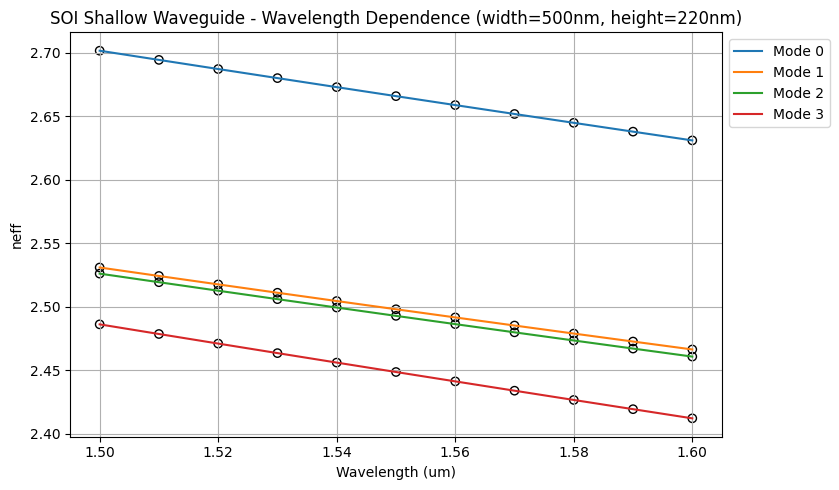

In [47]:
# SOI shallow waveguide - wavelength sweep
wavelength_soi = np.linspace(1500, 1600, 11) * nm

soi_shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength_soi,
    core_width=500 * nm,  # 500 nm width
    core_thickness=220 * nm,  # 220 nm height
    slab_thickness=150 * nm,  # Shallow etched
    core_material='si',  # Silicon core
    clad_material='sio2',  # SiO2 cladding
    num_modes=4,
    cache_path='.cache_soi/',  # use a fresh cache to avoid corrupted files
    overwrite=True,             # force recomputation instead of loading old cache
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

res_neff_soi_shallow = soi_shallow_waveguide.n_eff
res_te_soi_shallow = soi_shallow_waveguide.fraction_te
res_tm_soi_shallow = soi_shallow_waveguide.fraction_tm

plt.figure(figsize=(10, 5))
for k in range(res_neff_soi_shallow.shape[1]):
    plt.scatter(wavelength_soi, res_neff_soi_shallow[:,k].real, edgecolors='k', facecolors='none', label='__nolegend__')
    plt.plot(wavelength_soi, res_neff_soi_shallow[:,k].real, label=f'Mode {k}')

plt.title(f"SOI Shallow Waveguide - Wavelength Dependence (width=500nm, height=220nm)")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### LO.3 Extended - SOI Width Dependence

Analyze the width dependence for SOI deep waveguide at 1550 nm. Sweep width from 300 nm to 1 um.

  0%|          | 0/15 [00:00<?, ?it/s]

2026-03-15 12:02:32.584 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-03-15 12:02:32.595 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f4d091e2b988ab19.npz.
2026-03-15 12:02:32.598 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e1f04813ebcce43a.npz.
2026-03-15 12:02:32.600 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6899bf2cf261b966.npz.
2026-03-15 12:02:32.603 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-03-15 12:02:32.605 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ca66b4a9979bdc03.npz.
2026-03-15 12:02:32.608 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_401cb9732cf25023.npz.
2026-03-15 12:02:32.611 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0ef0e42a2ac15fde.npz.


  0%|          | 0/15 [00:00<?, ?it/s]

2026-03-15 12:02:32.644 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-03-15 12:02:32.647 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f4d091e2b988ab19.npz.
2026-03-15 12:02:32.650 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e1f04813ebcce43a.npz.
2026-03-15 12:02:32.654 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6899bf2cf261b966.npz.
2026-03-15 12:02:32.656 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-03-15 12:02:32.658 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ca66b4a9979bdc03.npz.
2026-03-15 12:02:32.661 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_401cb9732cf25023.npz.
2026-03-15 12:02:32.664 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0ef0e42a2ac15fde.npz.


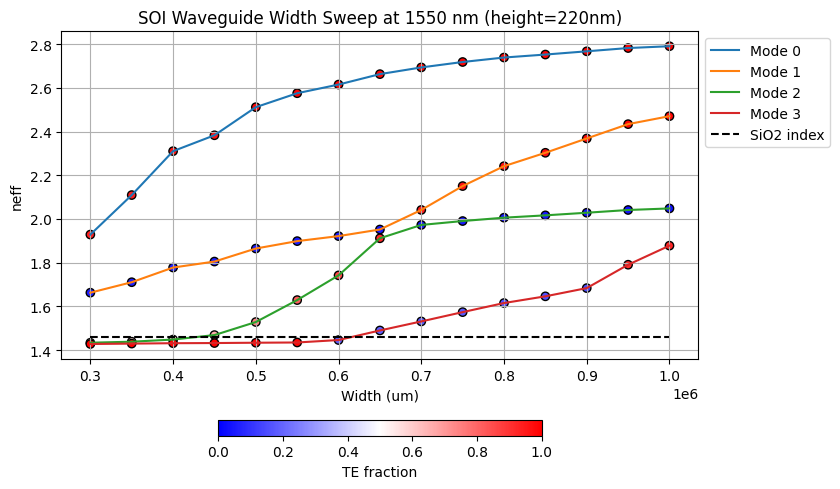

In [48]:
# SOI waveguide width sweep at 1550 nm
wavelength_fixed = 1550 * nm

soi_wg_sweep = gt.modes.Waveguide(
    wavelength=wavelength_fixed,
    core_width=500 * nm,  
    core_thickness=220 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

# Sweep widths from 300 nm to 1 um
w_soi = np.arange(300, 1050, 50) * nm  # widths in meters

sweep_neff_soi = gt.modes.sweep_n_eff(soi_wg_sweep, core_width=w_soi)
sweep_te_soi = gt.modes.sweep_fraction_te(soi_wg_sweep, core_width=w_soi)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff_soi.shape[1]):
    plt.scatter(w_soi*1e6, sweep_neff_soi[:,k].real, edgecolors='k', c=sweep_te_soi.sel(mode_index=k), 
                vmin=0, vmax=1, label='__nolegend__', cmap='bwr')
    plt.plot(w_soi*1e6, sweep_neff_soi[:,k].real, label=f'Mode {k}')

plt.title("SOI Waveguide Width Sweep at 1550 nm (height=220nm)")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w_soi*1e6), xmax=np.max(w_soi*1e6), colors='k', linestyles='dashed', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
cbar = plt.colorbar(orientation='horizontal', fraction=0.04)
cbar.set_label("TE fraction")

To explain clearly what happen with the modes we see the field representation of the modes

2026-03-15 12:06:02.002 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.


2026-03-15 12:06:02.029 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-03-15 12:06:02.052 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_07b520dc17f68bb3.npz.


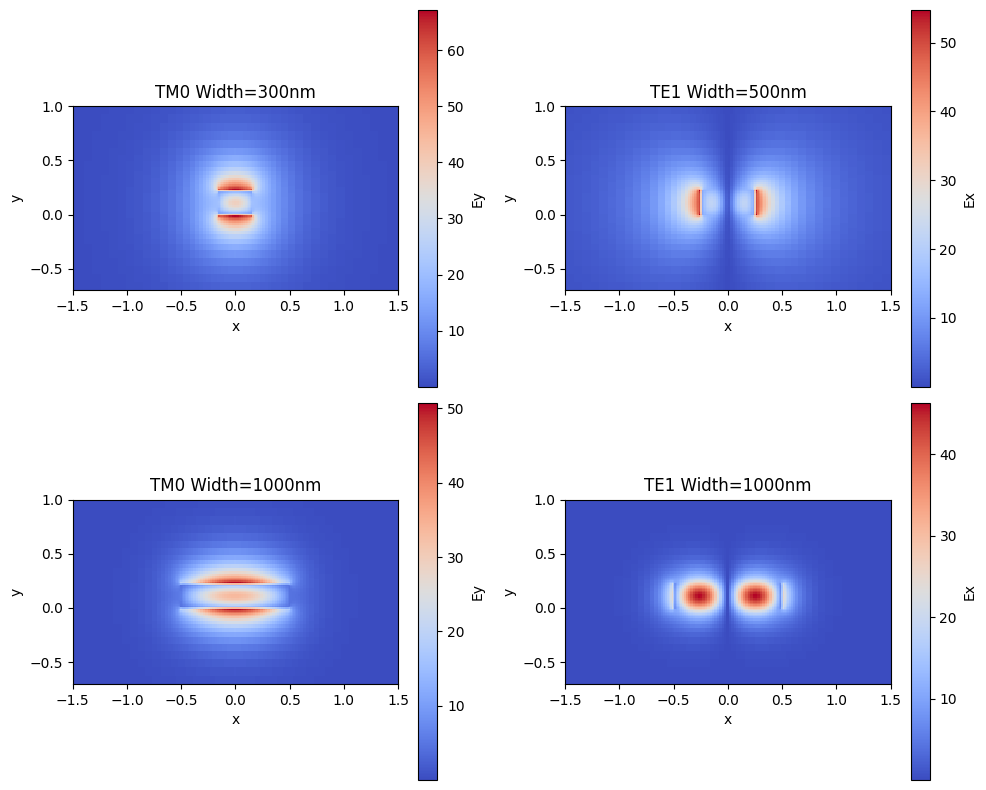

In [52]:
bend_1550_300 = gt.modes.Waveguide(
    wavelength=1550 * nm,  # Wavelength to be simulated
    core_width=300 * nm,  # Initial width for sweep object
    core_thickness=220 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

bend_1550_300.plot_field(field_name="Ey", mode_index=1, value='abs',
                     cmap='coolwarm', xlim=(-1.5, 1.5), ylim=(-0.7, 1),
                     ax=axes[0, 0])
axes[0, 0].set_title('TM0 Width=300nm')

bend_1550_500 = gt.modes.Waveguide(
    wavelength=1550 * nm,  # Wavelength to be simulated
    core_width=500 * nm,  # Unic variation
    core_thickness=220 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

bend_1550_500.plot_field(field_name="Ex", mode_index=2, value='abs',
                     cmap='coolwarm', xlim=(-1.5, 1.5), ylim=(-0.7, 1),
                     ax=axes[0, 1])
axes[0, 1].set_title('TE1 Width=500nm')

bend_1550_1000 = gt.modes.Waveguide(
    wavelength=1550 * nm,  # Wavelength to be simulated
    core_width=1000 * nm,  # Unic variation
    core_thickness=220 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)

bend_1550_1000.plot_field(field_name="Ey", mode_index=2, value='abs',
                     cmap='coolwarm', xlim=(-1.5, 1.5), ylim=(-0.7, 1),
                     ax=axes[1, 0])
axes[1, 0].set_title('TM0 Width=1000nm')

bend_1550_1000.plot_field(field_name="Ex", mode_index=1, value='abs',
                     cmap='coolwarm', xlim=(-1.5, 1.5), ylim=(-0.7, 1),
                     ax=axes[1, 1])
axes[1, 1].set_title('TE1 Width=1000nm')

plt.tight_layout()
plt.show()


### LO.5 Extended - SOI Bend Loss Analysis

Find the safe radius for SOI technology. Sweep radius from 5 um to 30 um and calculate bend losses.

  0%|          | 0/5 [00:00<?, ?it/s]

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

2026-03-15 12:13:54.720 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dc3d1854e26bf6af.npz.
2026-03-15 12:13:54.733 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_190a435d611d6ac0.npz.
2026-03-15 12:13:54.735 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_85c10aea39f94d70.npz.
2026-03-15 12:13:54.737 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2377aa86a97b4c91.npz.
2026-03-15 12:13:54.739 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_38ad43eb04993d38.npz.


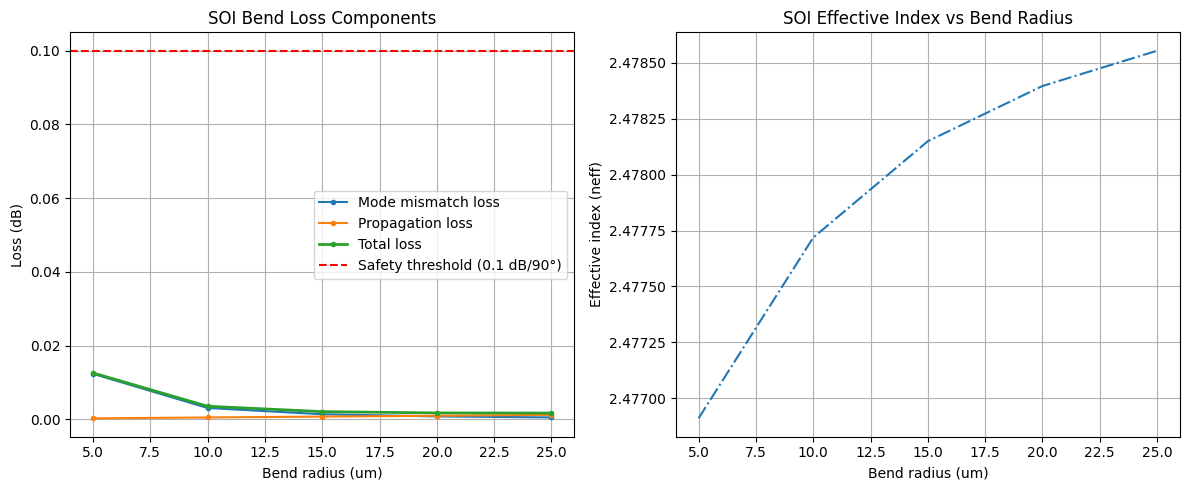

In [62]:
# SOI bend loss analysis - radius sweep from 5 um to 30 um
radii_soi = np.arange(5,30, 5)  # 5 um to 30 um range

# Create base waveguide for SOI
bend_soi_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=500 * nm,
    core_thickness=220 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30,
    bend_radius=5,  # Initial bend radius
)

mismatch_soi = gt.modes.sweep_bend_mismatch(bend_soi_1550, radii_soi)

dB_cm_soi = 0.3  # dB/cm for SOI (less loss than SiNx)
length_soi = 0.5 * np.pi * radii_soi * 1e-6  # Arc length for 90 degree bend
propagation_loss_soi = dB_cm_soi * length_soi * 1e2

# Total loss
total_loss_soi = propagation_loss_soi - 10 * np.log10(mismatch_soi)

plt.figure(figsize=(12, 5))

# Loss components
plt.subplot(1, 2, 1)
plt.plot(radii_soi, -10 * np.log10(mismatch_soi), ".-", label="Mode mismatch loss")
plt.plot(radii_soi, propagation_loss_soi, ".-", label="Propagation loss")
plt.plot(radii_soi, total_loss_soi, ".-", linewidth=2, label="Total loss")
plt.axhline(y=0.1, color='r', linestyle='--', label='Safety threshold (0.1 dB/90°)')
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.title("SOI Bend Loss Components")
plt.legend()
plt.grid()

# Effective index variation with bend radius
neff_values_soi = []
for R in radii_soi:
    bend_wg_soi = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=500 * nm,
        core_thickness=220 * nm,
        slab_thickness=0.0,
        core_material='si',
        clad_material='sio2',
        num_modes=1,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30,
        bend_radius=R,
    )
    neff_values_soi.append(bend_wg_soi.n_eff.real)

plt.subplot(1, 2, 2)
plt.plot(radii_soi, neff_values_soi, "-.")
plt.grid()
plt.title("SOI Effective Index vs Bend Radius")
plt.xlabel("Bend radius (um)")
plt.ylabel("Effective index (neff)")

plt.tight_layout()
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

12:26:02 CET WARNING: Mode field at frequency index 0, mode index 0 does not    
             decay at the plane boundaries.                                     

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

  0%|          | 0/3 [00:00<?, ?it/s]

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

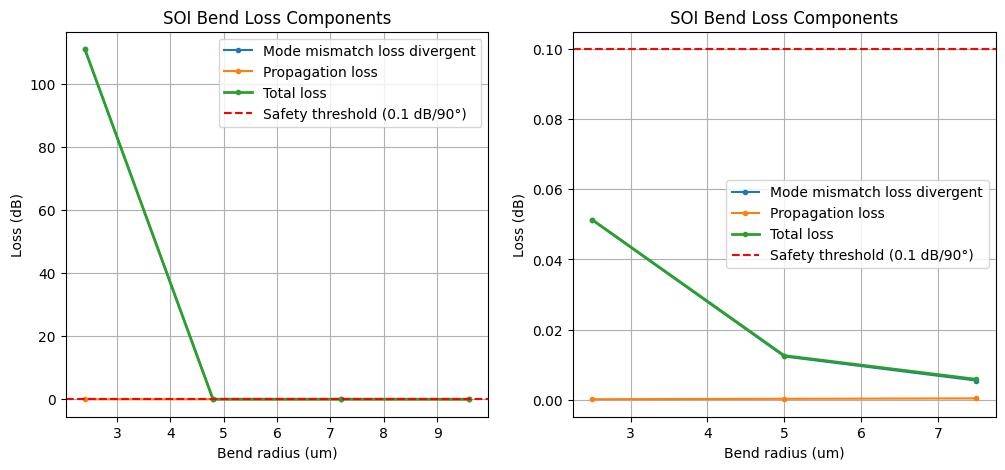

In [72]:
#Obtention of safe bend radius
radii_soi_1 = np.arange(2.4,10, 2.4)

mismatch_soi_1 = gt.modes.sweep_bend_mismatch(bend_soi_1550, radii_soi_1)

dB_cm_soi_1 = 0.3  # dB/cm for SOI (less loss than SiNx)
length_soi_1 = 0.5 * np.pi * radii_soi_1 * 1e-6  # Arc length for 90 degree bend
propagation_loss_soi_1 = dB_cm_soi_1 * length_soi_1 * 1e2

# Total loss
plt.figure(figsize=(12, 5))
total_loss_soi_1 = propagation_loss_soi_1 - 10 * np.log10(mismatch_soi_1)

# Loss components
plt.subplot(1, 2, 1)
plt.plot(radii_soi_1, -10 * np.log10(mismatch_soi_1), ".-", label="Mode mismatch loss divergent")
plt.plot(radii_soi_1, propagation_loss_soi_1, ".-", label="Propagation loss")
plt.plot(radii_soi_1, total_loss_soi_1 , ".-", linewidth=2, label="Total loss")
plt.axhline(y=0.1, color='r', linestyle='--', label='Safety threshold (0.1 dB/90°)')
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.title("SOI Bend Loss Components")
plt.legend()
plt.grid()

radii_soi_2 = np.arange(2.5,10, 2.5)

mismatch_soi_2 = gt.modes.sweep_bend_mismatch(bend_soi_1550, radii_soi_2)

dB_cm_soi_2 = 0.3  # dB/cm for SOI (less loss than SiNx)
length_soi_2 = 0.5 * np.pi * radii_soi_2 * 1e-6  # Arc length for 90 degree bend
propagation_loss_soi_2 = dB_cm_soi_2 * length_soi_2 * 1e2

# Total loss
total_loss_soi_2 = propagation_loss_soi_2 - 10 * np.log10(mismatch_soi_2)

# Loss components
plt.subplot(1, 2, 2)
plt.plot(radii_soi_2, -10 * np.log10(mismatch_soi_2), ".-", label="Mode mismatch loss divergent")
plt.plot(radii_soi_2, propagation_loss_soi_2, ".-", label="Propagation loss")
plt.plot(radii_soi_2, total_loss_soi_2 , ".-", linewidth=2, label="Total loss")
plt.axhline(y=0.1, color='r', linestyle='--', label='Safety threshold (0.1 dB/90°)')
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.title("SOI Bend Loss Components")
plt.legend()
plt.grid()

## Technology Comparison: SiNx vs SOI

Comprehensive comparison between Silicon Nitride (SiNx) and Silicon-On-Insulator (SOI) waveguide technologies.

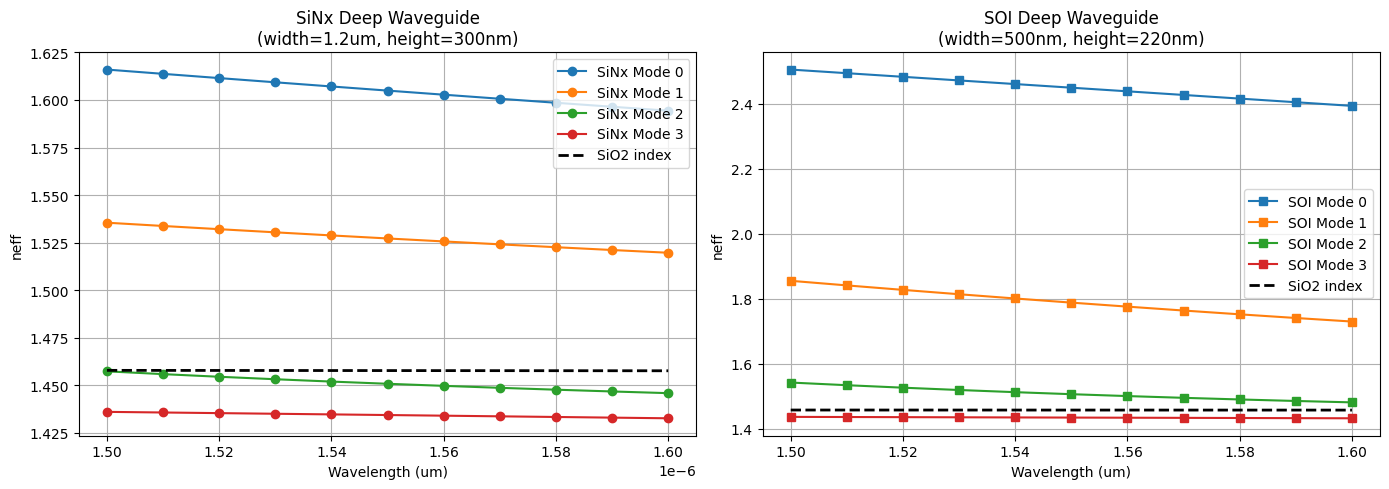

In [69]:
# We see results on image and then a summary table. 1.Wavelength dependence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SiNx comparison
ax = axes[0]
for k in range(min(4, res_neff.shape[1])):
    ax.plot(wavelength, res_neff[:,k].real, 'o-', label=f'SiNx Mode {k}')
ax.plot(wavelength, box_index, 'k--', linewidth=2, label='SiO2 index')
ax.set_title("SiNx Deep Waveguide\n(width=1.2um, height=300nm)")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("neff")
ax.grid()
ax.legend()

# SOI comparison
ax = axes[1]
for k in range(min(4, res_neff_soi_deep.shape[1])):
    ax.plot(wavelength_soi, res_neff_soi_deep[:,k].real, 's-', label=f'SOI Mode {k}')
ax.plot(wavelength_soi, box_index, 'k--', linewidth=2, label='SiO2 index')
ax.set_title("SOI Deep Waveguide\n(width=500nm, height=220nm)")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("neff")
ax.grid()
ax.legend()

plt.tight_layout()


  0%|          | 0/6 [00:00<?, ?it/s]

/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lorena/Escritorio/CIFOIN_MUIT/P1/ci

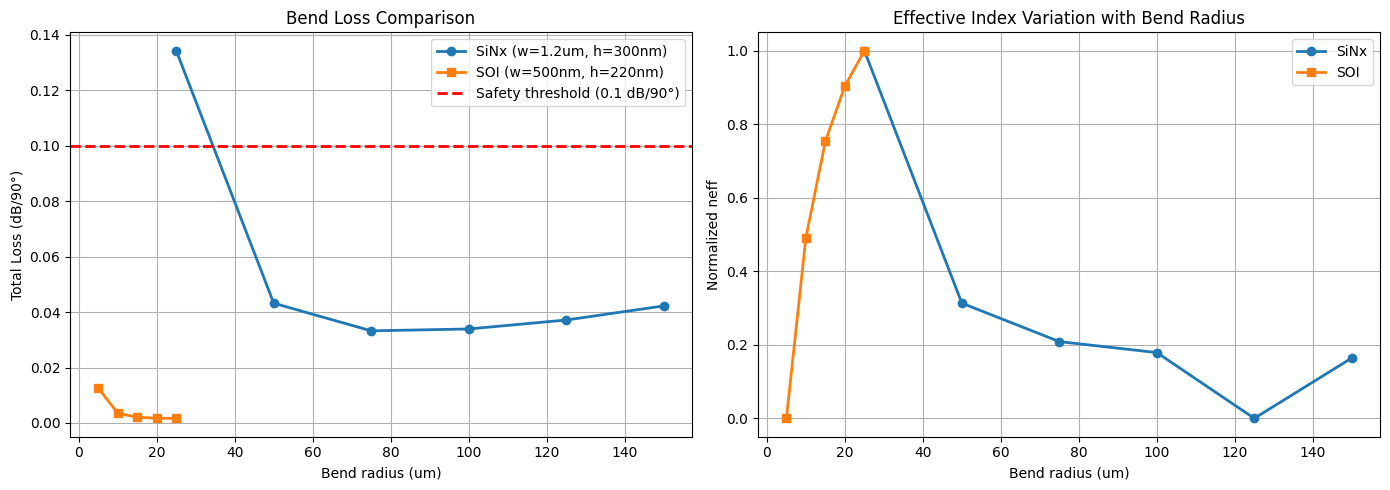

In [66]:
# 2. Bend Loss Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SiNx bend loss (from earlier analysis)
radii_sinx = np.arange(25.0, 175, 25)
length_sinx = 0.5 * np.pi * radii_sinx * 1e-6
propagation_loss_sinx = dB_cm * length_sinx * 1e2

bend_1550_sinx = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    core_thickness=300 * nm,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30,
    bend_radius=25,
)

mismatch_sinx = gt.modes.sweep_bend_mismatch(bend_1550_sinx, radii_sinx)
total_loss_sinx = propagation_loss_sinx - 10 * np.log10(mismatch_sinx)

# Plot comparisons
ax = axes[0]
ax.plot(radii_sinx, total_loss_sinx, "o-", linewidth=2, label="SiNx (w=1.2um, h=300nm)")
ax.plot(radii_soi, total_loss_soi, "s-", linewidth=2, label="SOI (w=500nm, h=220nm)")
ax.axhline(y=0.1, color='r', linestyle='--', linewidth=2, label='Safety threshold (0.1 dB/90°)')
ax.set_xlabel("Bend radius (um)")
ax.set_ylabel("Total Loss (dB/90°)")
ax.set_title("Bend Loss Comparison")
ax.grid()
ax.legend()

ax = axes[1]
# Normalize SiNx neff values
neff_values_sinx_norm = [(n - np.min(neff_values)) / (np.max(neff_values) - np.min(neff_values)) 
                          for n in neff_values]
neff_values_soi_norm = [(n - np.min(neff_values_soi)) / (np.max(neff_values_soi) - np.min(neff_values_soi)) 
                        for n in neff_values_soi]

ax.plot(radii_sinx, neff_values_sinx_norm, "o-", linewidth=2, label="SiNx")
ax.plot(radii_soi, neff_values_soi_norm, "s-", linewidth=2, label="SOI")
ax.set_xlabel("Bend radius (um)")
ax.set_ylabel("Normalized neff")
ax.set_title("Effective Index Variation with Bend Radius")
ax.grid()
ax.legend()

plt.tight_layout()

In [70]:
# Summary Table

print("\n" + "="*90)
print("COMPREHENSIVE TECHNOLOGY COMPARISON: SiNx vs SOI")
print("="*90)

comparison_data = {
    'Parameter': [
        'Core Material',
        'Core Refractive Index',
        'Cladding Material',
        'Cladding Index',
        'Core Width',
        'Core Height',
        'Slab Height',
        'Mode Confinement',
        'Dispersion',
        'Bend Losses',
        'Propagation Loss',
        'Safe Bend Radius',
        'Footprint',
        'CMOS Compatible',
        'Cost'
    ],
    'SiNx': [
        'Silicon Nitride (Si₃N₄)',
        '~2.0 @ 1550nm',
        'Silicon Dioxide (SiO₂)',
        '~1.457 @ 1550nm',
        '1.2 μm',
        '300 nm',
        '0 nm (deep etched)',
        'Moderate',
        'Low (good for filters)',
        'Moderate (~25 μm)',
        '~1.5 dB/cm',
        '~25 μm',
        'Larger (~1.2 μm)',
        'No',
        'Medium'
    ],
    'SOI': [
        'Silicon (Si)',
        '~3.5 @ 1550nm',
        'Silicon Dioxide (SiO₂)',
        '~1.457 @ 1550nm',
        '500 nm',
        '220 nm',
        '2 μm (BOX)',
        'Very High',
        'High (good for modulators)',
        'Very Low (~5 μm)',
        '~0.3 dB/cm',
        '~5-10 μm',
        'Very Small (<500nm)',
        'Yes',
        'Low'
    ]
}

# Print formatted table
col_width = 28
print(f"{'Parameter':<25} | {'SiNx':<{col_width}} | {'SOI':<{col_width}}")
print("-" * (25 + 2 + col_width*2 + 4))
for i, param in enumerate(comparison_data['Parameter']):
    sinx_val = comparison_data['SiNx'][i]
    soi_val = comparison_data['SOI'][i]
    print(f"{param:<25} | {sinx_val:<{col_width}} | {soi_val:<{col_width}}")



COMPREHENSIVE TECHNOLOGY COMPARISON: SiNx vs SOI
Parameter                 | SiNx                         | SOI                         
---------------------------------------------------------------------------------------
Core Material             | Silicon Nitride (Si₃N₄)      | Silicon (Si)                
Core Refractive Index     | ~2.0 @ 1550nm                | ~3.5 @ 1550nm               
Cladding Material         | Silicon Dioxide (SiO₂)       | Silicon Dioxide (SiO₂)      
Cladding Index            | ~1.457 @ 1550nm              | ~1.457 @ 1550nm             
Core Width                | 1.2 μm                       | 500 nm                      
Core Height               | 300 nm                       | 220 nm                      
Slab Height               | 0 nm (deep etched)           | 2 μm (BOX)                  
Mode Confinement          | Moderate                     | Very High                   
Dispersion                | Low (good for filters)       | High (good 

## Grading

LO.1. 1 Point <br> 
LO.2. 2 Points <br> 
LO.3. 1 Point <br> 
LO.4. 2 Points <br> 
LO.5. 1 Point <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
